In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize

In [2]:
df = pd.read_csv("https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv")

In [3]:
X = df.drop('variety', axis = 1)
Y = df['variety']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

In [5]:
svm = SVC(probability  =True, random_state = 42)
param_grid = {
    'C' : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'degree' : [2, 3, 4],
    'gamma': ['scale', 'auto']
}

In [6]:
grid_search = GridSearchCV(estimator = svm, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train, y_train)
best_model =  grid_search.best_estimator_
print("Best Hyperparameters: ", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters:  {'C': 1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


In [7]:
y_pred = best_model.predict(X_test)

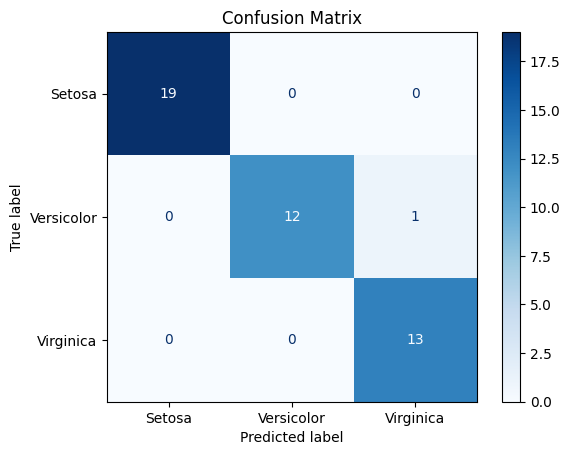

In [8]:
cm = confusion_matrix(y_test, y_pred, labels = best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = best_model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [10]:
report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report: ")
print(report)

Classification Report: 
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        19
  Versicolor       1.00      0.92      0.96        13
   Virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



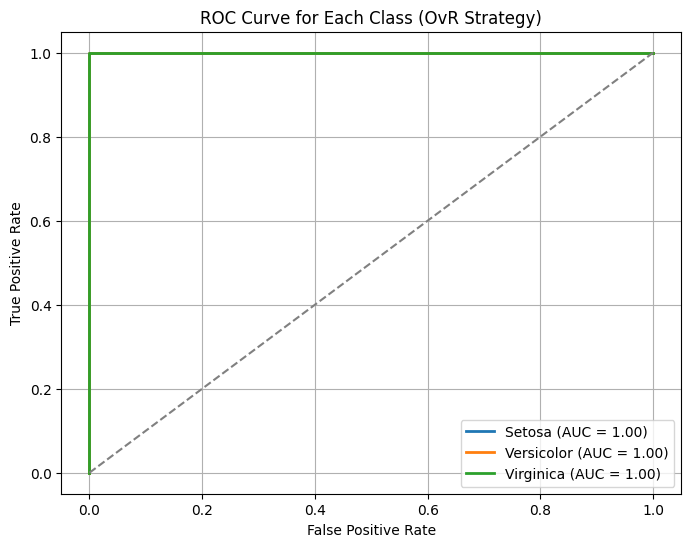

In [15]:
positive_class = 'Setosa'

# Binarizar correctamente para OvR
y_test_binarized = label_binarize(y_test, classes=list(best_model.classes_))
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label], tpr[class_label], lw=2,
             label=f'{class_label} (AUC = {roc_auc[class_label]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (OvR Strategy)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()